In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("blourdhuraju/intel-image-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'intel-image-classification-dataset' dataset.
Path to dataset files: /kaggle/input/intel-image-classification-dataset
Contents of base_path (/kaggle/input):
['intel-image-classification-dataset']
Contents of path (/kaggle/input/intel-image-classification-dataset):
['Intel-Image-Classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'test'))}")

Contents of the 'train' directory: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Contents of the 'test' directory: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']



--- Sample Images from Training Dataset (/kaggle/input/intel-image-classification-dataset/Intel-Image-Classification/train) ---
Found 12632 images in /kaggle/input/intel-image-classification-dataset/Intel-Image-Classification/train. Displaying 6 samples:


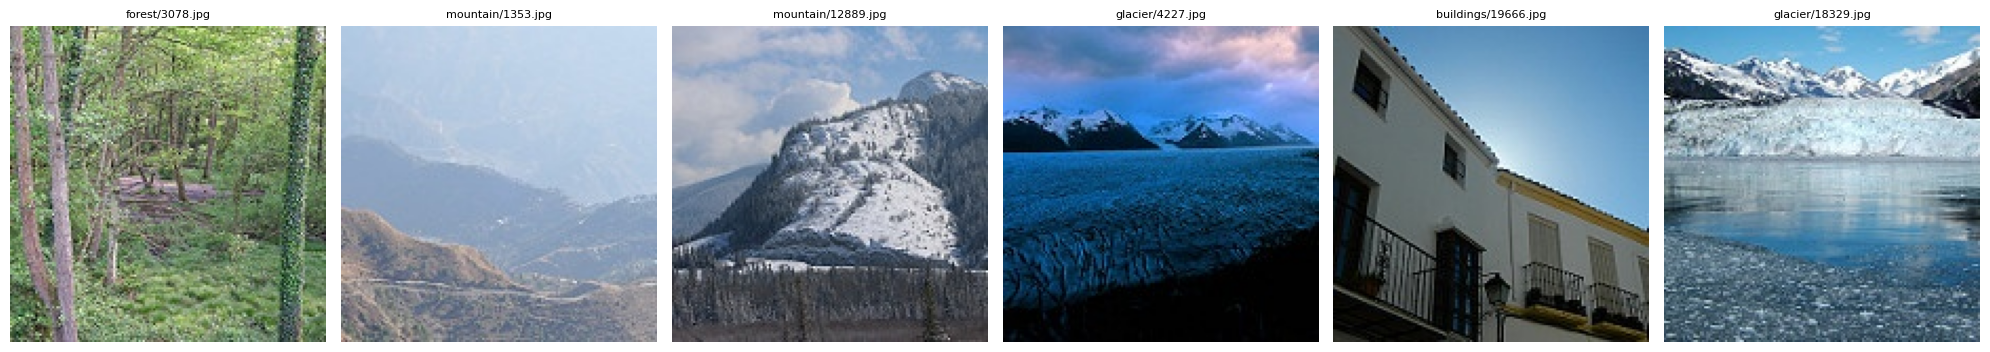


--- Sample Images from Test Dataset (/kaggle/input/intel-image-classification-dataset/Intel-Image-Classification/test) ---
Found 3000 images in /kaggle/input/intel-image-classification-dataset/Intel-Image-Classification/test. Displaying 6 samples:


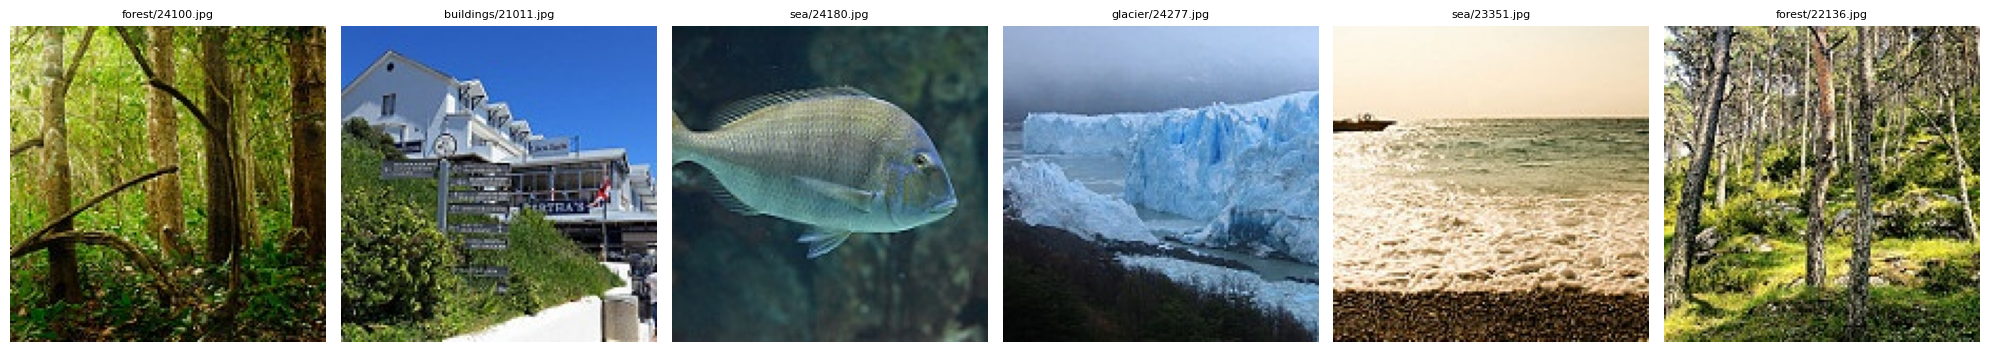

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Intel-Image-Classification' subdirectory
train_path = os.path.join(path, 'Intel-Image-Classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Intel-Image-Classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Optionally set memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found. Training will proceed on CPU, which might be slow.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 6

# Data Augmentation and Loading
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Model Building
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  # Freeze the foundation

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Corrected 'categorical_loss' to 'categorical_crossentropy'
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training (Small number of epochs for demonstration)
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Found 12632 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 166s 375ms/step - accuracy: 0.7619 - loss: 0.6776 - val_accuracy: 0.8577 - val_loss: 0.3717
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 102s 258ms/step - accuracy: 0.8167 - loss: 0.5010 - val_accuracy: 0.8587 - val_loss: 0.3532
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 100s 253ms/step - accuracy: 0.8253 - loss: 0.4823 - val_accuracy: 0.8787 - val_loss: 0.3196
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 101s 256ms/step - accuracy: 0.8300 - loss: 0.4585 - val_accuracy: 0.8727 - val_loss: 0.3239
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 102s 259ms/step - accuracy: 0.8389 - loss: 0.4343 - val_accuracy: 0.8830 - val_loss: 0.3018
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 106s 269ms/step - accuracy: 0.8379 - loss: 0.4364 - val_accuracy: 0.8657 - val_loss: 0.3284
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 138s 258ms/step - accuracy: 0.8427 - loss: 0.4245 - val_accuracy: 0.8710 - val_loss

In [ ]:
# Summarize training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy:   0.8449
Final Validation Accuracy: 0.8903
Final Training Loss:       0.4199
Final Validation Loss:     0.2920


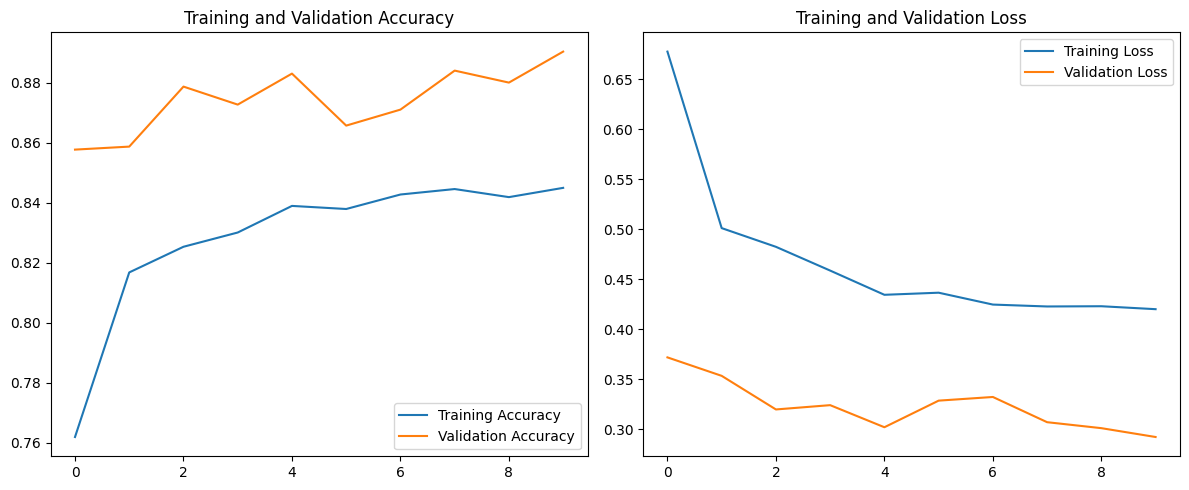

In [ ]:
import matplotlib.pyplot as plt

# Plotting Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()